# Bài Thực Hành Lab 02: Tóm Tắt Dữ Liệu Phân Loại & Dữ Liệu Số
**Học phần:** UET.MAT1052 — Xác suất thống kê (VNU-UET)
---
### Mục tiêu bài học:
1. **Dữ liệu phân loại:** Tần số, tỉ lệ, bảng liên hợp `crosstab()`, hiểu rõ các mẫu số `normalize='index'` / `'columns'` / `'all'`.
2. **Dữ liệu số:** Trung bình (Mean), Trung vị (Median), Phương sai, Độ lệch chuẩn, Tứ phân vị, IQR, `describe()`.
3. **Kiểm chứng lý thuyết:** Tính bền vững (Robustness) trước ngoại lai; Biến đổi tuyến tính $Y = aX + b$; Tổn thất bình phương $L(a) = /sum (x_i - a)^2$.
4. **Trực quan hóa:** Histogram và Boxplot phát hiện ngoại lai với Matplotlib và Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4.5)

Matplotlib is building the font cache; this may take a moment.


## 1. Tóm Tắt Dữ Liệu Phân Loại (Palmer Penguins)
Khảo sát biến loài (`species`) và đảo sinh sống (`island`).

In [ ]:
penguins = pd.read_csv("C:/Users/SONY/Downloads/penguins.csv")

# 1. Số đếm và tỉ lệ một chiều
print("--- Số đếm từng loài ---")
display(penguins['species'].value_counts())

print("/n--- Tỉ lệ từng loài ---")
display(penguins['species'].value_counts(normalize=True).round(3))

# 2. Bảng liên hợp hai chiều (Contingency table)
print("/n--- Bảng liên hợp species x island (có tổng viền) ---")
display(pd.crosstab(penguins['species'], penguins['island'], margins=True))

--- Số đếm từng loài ---


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

/n--- Tỉ lệ từng loài ---


species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.198
Name: proportion, dtype: float64


--- Bảng liên hợp species x island (có tổng viền) ---


island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
All,168,124,52,344


### Thử thách về mẫu số trong `crosstab` (W02-PY01)
- `normalize='index'`: Tính theo hàng (tổng mỗi hàng = 1.0) -> *Phân bố các đảo trong từng loài*.
- `normalize='columns'`: Tính theo cột (tổng mỗi cột = 1.0) -> *Cơ cấu các loài trên từng đảo*.

In [ ]:
print("--- Tỉ lệ theo hàng (Đảo trong từng loài) ---")
display(pd.crosstab(penguins['species'], penguins['island'], normalize='index').round(3))

print("/n--- Tỉ lệ theo cột (Loài trên từng đảo) ---")
display(pd.crosstab(penguins['species'], penguins['island'], normalize='columns').round(3))

--- Tỉ lệ theo hàng (Đảo trong từng loài) ---


island,Biscoe,Dream,Torgersen
species,,,
Adelie,0.289,0.368,0.342
Chinstrap,0.000,1.000,0.000
Gentoo,1.000,0.000,0.000



--- Tỉ lệ theo cột (Loài trên từng đảo) ---


island,Biscoe,Dream,Torgersen
species,,,
Adelie,0.262,0.452,1.0
Chinstrap,0.000,0.548,0.0
Gentoo,0.738,0.000,0.0


## 2. Tóm Tắt Dữ Liệu Số & Kiểm Chứng Lý Thuyết

In [10]:
# Dãy gốc STAT 20
x = pd.Series([8, 11, 7, 7, 8, 11, 9, 6, 10, 7, 9])
print(f"Dãy gốc: Mean = {x.mean():.3f}, Median = {x.median()}, SD = {x.std():.3f}, IQR = {x.quantile(0.75)-x.quantile(0.25):.3f}")

# Thay 6 bằng -200 (W02-EX07 / W02-CH02)
x_bad = pd.Series([8, 11, 7, 7, 8, 11, 9, -200, 10, 7, 9])
print(f"Sau thay đổi: Mean = {x_bad.mean():.3f}, Median = {x_bad.median()}, SD = {x_bad.std():.3f}, IQR = {x_bad.quantile(0.75)-x_bad.quantile(0.25):.3f}")

Dãy gốc: Mean = 8.455, Median = 8.0, SD = 1.695, IQR = 2.500
Sau thay đổi: Mean = -10.273, Median = 8.0, SD = 62.943, IQR = 2.500


### Kiểm chứng biến đổi thang đo tuyến tính $Y = 3X + 5$ (W02-PY05)

In [11]:
y = 3 * x + 5
print("X: Mean =", round(x.mean(), 3), "SD =", round(x.std(), 3), "IQR =", x.quantile(0.75) - x.quantile(0.25))
print("Y: Mean =", round(y.mean(), 3), "SD =", round(y.std(), 3), "IQR =", y.quantile(0.75) - y.quantile(0.25))

X: Mean = 8.455 SD = 1.695 IQR = 2.5
Y: Mean = 30.364 SD = 5.085 IQR = 7.5


## 3. Trực Quan Hóa Với Histogram & Boxplot

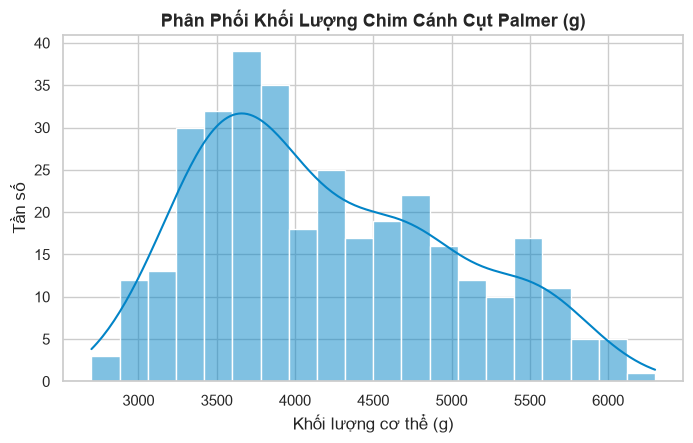

C:\Users\SONY\AppData\Local\Temp\ipykernel_7332\233645876.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins, x="species", y="body_mass_g", palette=["#38bdf8", "#ff7a59", "#10b981"])


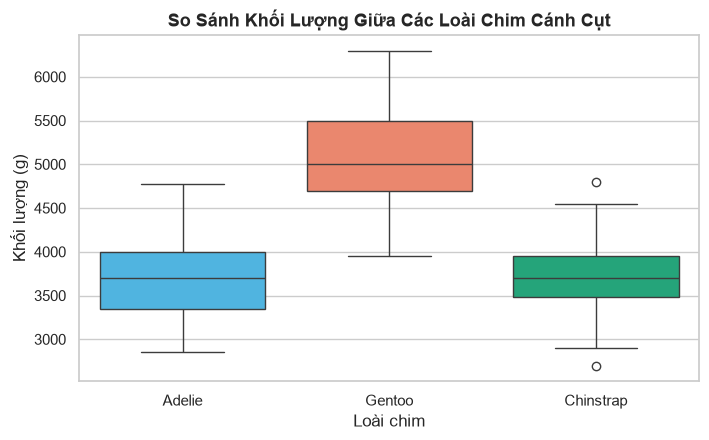

In [12]:
# 1. Histogram khối lượng cơ thể chim cánh cụt
plt.figure(figsize=(8, 4.5))
sns.histplot(data=penguins, x="body_mass_g", bins=20, kde=True, color="#0284c7")
plt.title("Phân Phối Khối Lượng Chim Cánh Cụt Palmer (g)", fontsize=13, fontweight='bold')
plt.xlabel("Khối lượng cơ thể (g)")
plt.ylabel("Tần số")
plt.show()

# 2. Boxplot so sánh khối lượng giữa 3 loài chim cánh cụt
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=penguins, x="species", y="body_mass_g", palette=["#38bdf8", "#ff7a59", "#10b981"])
plt.title("So Sánh Khối Lượng Giữa Các Loài Chim Cánh Cụt", fontsize=13, fontweight='bold')
plt.xlabel("Loài chim")
plt.ylabel("Khối lượng (g)")
plt.show()

## 4. Phân Tích Khảo Sát Sinh Viên UET (`uet_class_survey.csv`)

,id,khoa,nganh_hoc,gpa,gio_tu_hoc_tuan,thoi_gian_den_truong_phut,so_coc_ca_phe_tuan,tu_tin_lap_trinh_r,mua_yeu_thich,dia_hinh_yeu_thich,dinh_huong_nghe_nghiep
0,1,QH-2024-I/CQ,CNTT,3.16,3.8,7,2,5,Thu,Bien,KySuPhanMem
1,2,QH-2022-I/CQ,KhoaHocMayTinh,2.68,2.3,10,2,3,Ha,Bien,ChuyenGiaAI
2,3,QH-2022-I/CQ,TriTueNhanTao,3.41,5.9,10,6,6,Ha,Bien,KySuPhanMem
3,4,QH-2023-I/CQ,DTVT,2.99,17.7,22,6,5,Thu,Nui,ChuyenGiaAI
4,5,QH-2023-I/CQ,KhoaHocMayTinh,3.15,5.1,13,3,7,Xuan,Bien,ChuyenGiaAI


--- Thống kê mô tả điểm GPA ---


count    500.000
mean       3.194
std        0.383
min        2.100
25%        2.930
50%        3.210
75%        3.480
max        3.980
Name: gpa, dtype: float64

C:\Users\SONY\AppData\Local\Temp\ipykernel_7332\543634224.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=survey, x="nganh_hoc", y="gpa", palette="Set2")


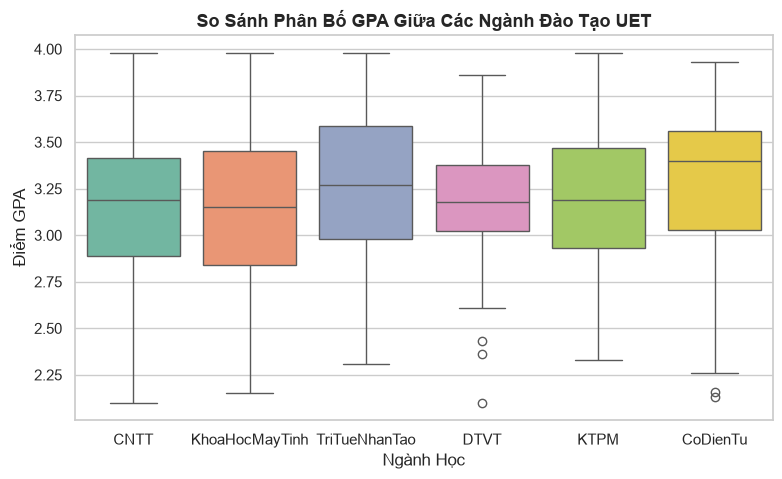

In [14]:
survey = pd.read_csv("C:/Users/SONY/Downloads/uet_class_survey.csv")
display(survey.head())

print("--- Thống kê mô tả điểm GPA ---")
display(survey['gpa'].describe().round(3))

# Boxplot GPA theo ngành học
plt.figure(figsize=(9, 5))
sns.boxplot(data=survey, x="nganh_hoc", y="gpa", palette="Set2")
plt.title("So Sánh Phân Bố GPA Giữa Các Ngành Đào Tạo UET", fontsize=13, fontweight='bold')
plt.xlabel("Ngành Học")
plt.ylabel("Điểm GPA")
plt.show()